In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


# examining power calculations for diagnostic tests - GO TO BOTTOM FOR ACTUAL EXPLANATION

Relevant readings
https://pmc.ncbi.nlm.nih.gov/articles/PMC6921417/
https://www.sciencedirect.com/science/article/pii/S0895435607001564?via%3Dihub#bib1


In [44]:
sensitivity = 0.85
specificity = 0.83

prevalence = 0.05

In [45]:
pop = 10000000

df = pd.DataFrame({'pop': range(pop)})
df["disease"] = np.random.binomial(1, prevalence, pop)
cases = df[df["disease"] == 1].copy()
controls = df[df["disease"] == 0].copy()
cases["test"] = np.random.binomial(1, sensitivity, len(cases))
controls["test"] = np.random.binomial(1, 1-specificity, len(controls))
df.loc[cases.index, "test"] = cases["test"]
df.loc[controls.index, "test"] = controls["test"]
# check the sensitivity and specificity
print(f" sensitivity: {df[df['disease'] == 1]['test'].mean()}")
print(f" specificity: {1-df[df['disease'] == 0]['test'].mean()}")

 sensitivity: 0.85021591239267
 specificity: 0.8301985431990784


In [46]:
ppv = df[df['test'] == 1]['disease'].mean()
npv = df[df['test'] == 0]['disease'].mean()
print(f" PPV: {ppv}")
print(f" NPV: {npv}")

 PPV: 0.20823607705641814
 NPV: 0.009387714400682807


In [47]:
prevalence * sensitivity / (prevalence * sensitivity + (1-prevalence) * (1-specificity))


0.20833333333333331

alpha is the signifince

beta is the "power"

In [48]:
# example power calculation
alpha = 0.05
beta = 0.2
power = 1-beta

# assume we want to power a diagnositc stufy to demonstrate a sensitivity of at least 0.75 -


Key step: NB: CI of a proporition is 

$$ sd(p) = \sqrt{\dfrac{p(1-p)}{n}}
\\
p(1-p) = var~of~a~bernoulli~trial
\\
\dfrac{p(1-p)}{n} = sample~var~of~proportion
\\
\sqrt{\dfrac{p(1-p)}{n}} = sqmple~sd
\\
z_{\dfrac{\alpha}{2}}\sqrt{\dfrac{p(1-p)}{n}} = margin~of~errror
$$
rearrnge for n

$$
n = \dfrac{p(1-p)}{ME^2}*{z_{\dfrac{\alpha}{2}}}^2
$$
want a CI of 95% = so 
$$\alpha = 1 - CI = 0.05\\
z_{\dfrac{\alpha}{2}} = z_{0.025} = 1.96$$

we want a ME of 0.1 (arbitrary)

so ...

$$

n = \dfrac{p(1-p)}{0.1^2}*1.96^2
$$
setting p to be 0.85

we get





In [49]:
#if we want 0.05 for specificity fo 0.83 the ...
n = (specificity*(1-specificity))/(0.05**2) * 1.96**2
print(n)

216.819904


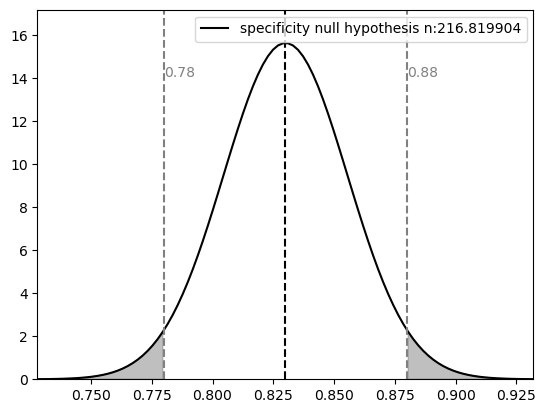

In [50]:
# visualise this

# center values for visualization purposes
n = n
mu = specificity
sigma = np.sqrt(specificity*(1-specificity)/n)
x = np.linspace(mu-4*sigma,mu+4*sigma,100)
y = stats.norm.pdf(x,mu,sigma)

# calculate the z-score for the lower and upper bounds
z = stats.norm.ppf(1-alpha/2,0,1)

plt.plot(x,y,color='black',label=f'specificity null hypothesis n:{n}')
plt.axvline(specificity,color='black',linestyle='--')
plt.axvline(specificity-z*sigma,color='grey',linestyle='--')
plt.text(specificity-z*sigma,max(y)*0.9,f'{specificity-z*sigma:.2f}',color='grey')
plt.axvline(specificity+z*sigma,color='grey',linestyle='--')
plt.text(specificity+z*sigma,max(y)*0.9,f'{specificity+z*sigma:.2f}',color='grey')

plt.fill_between(x,y,where=(x>=specificity+z*sigma) | (x<=specificity-z*sigma),color='grey',alpha=0.5)

plt.ylim(0,max(y)*1.1)
plt.xlim(min(x),max(x))

plt.legend()




This makes sense - we have calculate N such that the 95% CI falls on 78 (so our delta is 0.05) this means ....

If we take a sample of size n from a population in which p has mean 0.83 and sd ...

we would only expect the sample mean to be less than 0.78 2.5% of the time - hence if we detect this in our sample we can reject that 

### slighlty strange - so we interpret this to say that when we run our experiment we will have a sensitivity of >0.78 95% of the time

## This is $$H0:~ the~ "mean"~ is ~0.83$$, so the complement is that the mean is not 0.83 which is what we test with hypothesis 0

This makes sense in the context of powering RCTs where if we observe a effect greater than hte threshold we can say with confidence that it was not due to change - slightly unclear what it means in this diagnostic test context

Text(0.5, 1.0, "proportion of CI's that contain the true mean: 0.9542")

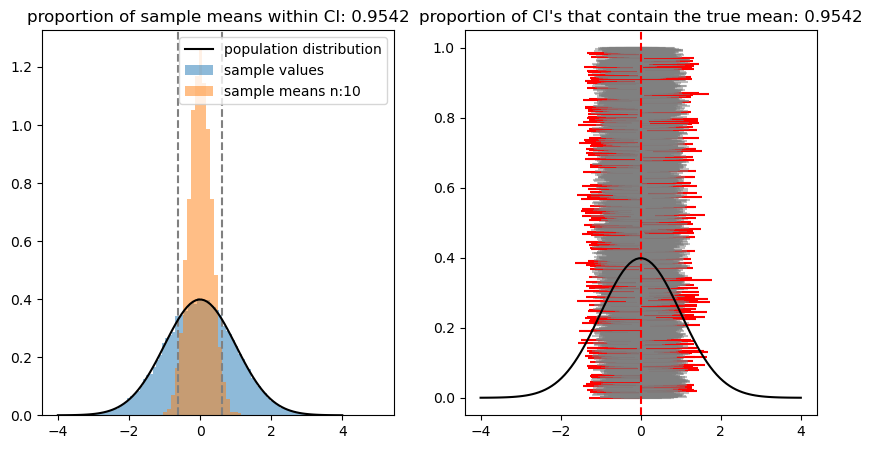

In [51]:
### double diversion - interpreting the CI
# question - is it that the sample mean will fall within the CI 95% of the time? of that the CI will contain the true mean 95% of the time?
# or are these equivalent?
sample_size = 10
n_samples = 5000
x = np.linspace(-4,4,100)
y = stats.norm.pdf(x,0,1)
alpha = 0.05
# calculate the z-score for the lower and upper bounds
z = stats.norm.ppf(1-alpha/2,0,1)
CI = [0-z*(1/np.sqrt(sample_size)),0+z*(1/np.sqrt(sample_size))]

samples = np.array([np.random.normal(0,1,sample_size) for _ in range(n_samples)])
sample_means = [np.mean(sample) for sample in samples]

# porportion of sample means within CI
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].axvline(CI[0],color='grey',linestyle='--')
ax[0].axvline(CI[1],color='grey',linestyle='--')
ax[0].plot(x,y,color='black',label=f'population distribution')
ax[0].hist(samples.flatten(),bins=100,density=True,alpha=0.5,label='sample values');
ax[0].hist(sample_means,bins=20,density=True,alpha=0.5,label=f'sample means n:{sample_size}');
ax[0].set_title(f"proportion of sample means within CI: {((sample_means > CI[0]) & (sample_means < CI[1])).mean()}")
ax[0].legend();

# porportion of sample CI's that contain the true mean
def ci_range(sample,z=z):
    return (np.mean(sample)-z*1/np.sqrt(sample_size),
            np.mean(sample)+z*1/np.sqrt(sample_size))

y_bar = np.linspace(0,1,n_samples)
sample_CIs = np.apply_along_axis(ci_range,1,samples)
for i,sample_CI in enumerate(sample_CIs):
    color = 'grey'
    image_alpha = 0.5
    if sample_CI[0] > 0 or sample_CI[1] < 0:
        color = 'red'
        image_alpha = 1
    ax[1].hlines(y=y_bar[i],xmin=sample_CI[0],xmax=sample_CI[1],color=color,linestyle='-',alpha=image_alpha)

ax[1].axvline(0,color='red',linestyle='--')
ax[1].plot(x,y,color='black',label=f'population distribution')

#ax[1].hist(CI_bars,bins=20,density=True,alpha=0.5,label=f'CI bars n:{sample_size}');
ax[1].set_title(f"proportion of CI's that contain the true mean: {((sample_CIs[:,0] < 0) & (sample_CIs[:,1] > 0)).mean()}")
#ax[1].legend();

# Q.I.D equivalent


# $$ but ~ this ~ is ~ not ~ what ~is ~actually~ being ~ done! $$ 

# $$incorporating~\beta$$

https://en.wikipedia.org/wiki/Power_(statistics)

from wikipedia -well written: "a typical statistical test would be based on a test statistic t calculated from the sampled data, which has a particular probability distribution under H 0 {\displaystyle H_{0}}. A desired significance level α would then define a corresponding "rejection region" (bounded by certain "critical values"), a set of values t is unlikely to take if H 0 {\displaystyle H_{0}} was correct. If we reject H 0 {\displaystyle H_{0}} in favor of H 1 {\displaystyle H_{1}} only when the sample t takes those values, we would be able to keep the probability of falsely rejecting H 0 {\displaystyle H_{0}} within our desired significance level. **At the same time, if H 1 {\displaystyle H_{1}} defines its own probability distribution for t** (the difference between the two distributions being a function of the effect size), the power of the test would be the probability, under H 1 {\displaystyle H_{1}}, that the sample t falls into our defined rejection region and causes H 0 {\displaystyle H_{0}} to be correctly rejected.

Beta is the probability of a type II error - of false negative

so we "power" the test to be 1-beta

this gives us the probability of detecting a true positive if it exists and thus the confidence to say that our null finding is meaningful and FN

**NB: this is contingent on the assumption that the TRUE specificity(p) is what we estimate it to be - and hte alternative hypothesis having a distribution htat we pick**


**RCT ANALOGY: we want to be x% confident that we will detect a true positive if it exists - e.g. the sample mean is greater than z_alpha*sigma**

# so now we frame this as an alternative hypothesis

$$ H1 $$ 
the "mean" of the population is actually 0.78
adn thus hte complement is that the mean in NOT 0.78

this sounds confusing but follow the math

# WE CAN THEN FIND A POINT BELOW WHICH HTERE IS A alpha CHANCE THAT THE SAMPLE MEAN FALLS GIVE DISTRIBUTION 1 
# AND ABOVE WHICH THERE IS A beta CHANCE THAT THE SAMPLE MEAN FALLS GIVEN DISTRIBUTION 2

So this gives us a low chance of type 1 error given distriubtion 1 - incorrectly saying htat the mean is not 0.83
and a low chance of type 2 error - not rejecting the false alternative hypothesis

This sencond part is key in our diagnostic interpretation - we want to "prove" with beta confidence that the specificity (proportion mean) is at least 0.78 - so we set up hte alternative hypothesis that the mean in 0.78 and "prove" that it is higher

the exactly theshold is a balance between the 2 hypothesis but is fixed given all the other parameters - so we calculate it in tandem with the sample size required

### now we want to calculate a sample size such that 
1. The area below x for distribution 0 is 0.025 #probabilty of type 1 error (probabilty study mean would be below x if true mean is 0.83)
2. The area above x for disritbution 1 is 0.8 #probabilty of type 2 error (probabilty study mean would is greate above x if true mean was 0.78)


In [52]:
np.random.random()/10

0.0844553978443512

In [53]:
def plot_normal(ax,x,mu,sigma,p=0.05,type="two_sided",label="",color="grey"):
    
    y = stats.norm.pdf(x,mu,sigma)
    ax.plot(x,y,color='black')
    
    ax.axvline(mu,color='black',linestyle='--')
    text_height = max(y) + 5*(np.random.random()-0.5)
    if type == "two_sided":
        z = stats.norm.ppf(1-p/2,0,1)
        # lower bound
        ax.axvline(mu-z*sigma,color='grey',linestyle='--')
        ax.text(mu-z*sigma,text_height,f'{mu-z*sigma:.3f}',color=color)
        # upper bound
        ax.axvline(mu+z*sigma,color='grey',linestyle='--')
        ax.text(mu+z*sigma,text_height,f'{mu+z*sigma:.3f}',color=color)
        # fill both
        ax.fill_between(x,y,where=(x>=mu+z*sigma) | (x<=mu-z*sigma),color=color,alpha=0.5,label=label)
    elif type == "right":
        z = stats.norm.ppf(1-p,0,1)
        ax.axvline(mu+z*sigma,color='grey',linestyle='--')
        ax.text(mu+z*sigma,text_height,f'{mu+z*sigma:.3f}',color=color)
        ax.fill_between(x,y,where=(x>=mu+z*sigma),color=color,alpha=0.5,label=label)
    elif type == "left":
        z = stats.norm.ppf(1-p,0,1)
        ax.axvline(mu-z*sigma,color='grey',linestyle='--')
        ax.text(mu-z*sigma,text_height,f'{mu-z*sigma:.3f}',color=color)
        ax.fill_between(x,y,where=(x<=mu-z*sigma),color=color,alpha=0.5,label=label)

    return y


0.83 0.375632799419859


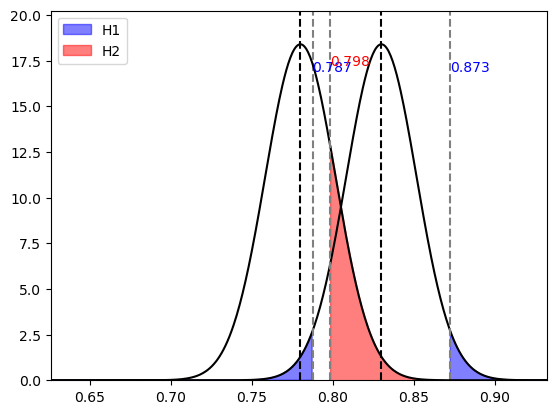

In [54]:
# visualise these 2 hypothesis with an arbitrary n number
specificity = 0.83
n = 300
delta = 0.05
alpha = 0.05
beta = 0.2

# distribution under H0 - mu = 0.83
mu0 = specificity
sigma0 = np.sqrt(specificity*(1-specificity)/n)
print(mu0,np.sqrt(specificity*(1-specificity)))
x = np.linspace(mu-8*sigma,mu+4*sigma,500)

# # calcualte hte distribution under H1 - mu = 0.78
mu1 = specificity - delta
sigma1 = np.sqrt(specificity*(1-specificity)/n)
# calculate the z-score for the upper bound
z1= stats.norm.ppf(1-beta,0,1)

fig, ax = plt.subplots()
y0 = plot_normal(ax,x,mu0,sigma0,p=alpha,type="two_sided",label="H1",color="blue")
y1 = plot_normal(ax,x,mu1,sigma1,p=beta,type="right",label="H2",color="red")

plt.ylim(0,max(max(y0),max(y1))*1.1)
plt.xlim(min(x),max(x))
plt.legend()

# now calculate N required to power study - this should make hte 2 thresholds line up

1 sample Z test for poropotions
$$Z = \dfrac{\hat{p} - p_0}{SE}$$

To ensure sufficient power we need to include $$Z_{\beta}$$

$$Z_{\alpha} + Z_{\beta} = \dfrac{\hat{p} - p_0}{SE}$$

taking from previous re-arranging

$$ n = \dfrac{p(1-p)}{ME^2}*({z_{\dfrac{\alpha}{2}}} +z_{{\beta}}) ^2 $$ 

note B is onesided


**NB: can reformulate equation to find CI = and solve for where CI overlap in the 2 hypotheses and you will get the above equation** 

In [55]:
alpha = 0.05
beta = 0.2
n = (specificity*(1-specificity)) / ((delta)**2) * ( stats.norm.ppf(1-0.05/2,0,1) + stats.norm.ppf(1-0.2,0,1))**2
n

442.9907722066626

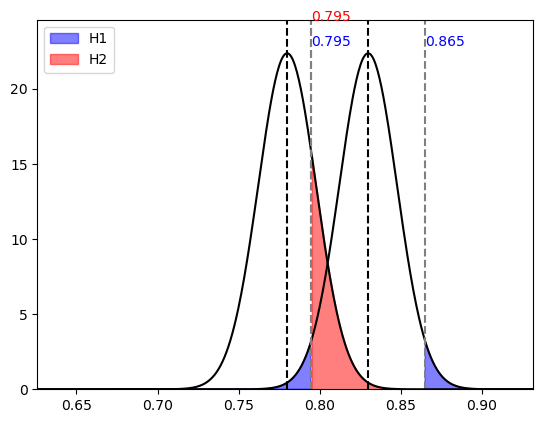

In [56]:
# visualise these 2 hypothesis the calculated
delta = 0.05
alpha = 0.05
beta = 0.2
n = (specificity*(1-specificity)) / ((delta)**2) * ( stats.norm.ppf(1-0.05/2,0,1) + stats.norm.ppf(1-0.2,0,1))**2

# distribution under H0 - mu = 0.83
mu0 = specificity
sigma0 = np.sqrt(specificity*(1-specificity)/n)
x = np.linspace(mu-8*sigma,mu+4*sigma,500)

# # calcualte hte distribution under H1 - mu = 0.78
mu1 = specificity - delta
# calculate the z-score for the upper bound
z1= stats.norm.ppf(1-beta,0,1)

fig, ax = plt.subplots()
y0 = plot_normal(ax,x,mu0,sigma0,p=0.05,type="two_sided",label="H1",color="blue")
y1 = plot_normal(ax,x,mu1,sigma0,p=0.2,type="right",label="H2",color="red")

plt.ylim(0,max(max(y0),max(y1))*1.1)
plt.xlim(min(x),max(x))
plt.legend()

# plot  sample size vs power

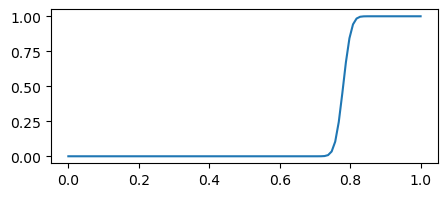

In [57]:
x_ = np.linspace(0,1,100)
plt.figure(figsize=(5,2))
plt.plot(x_,stats.norm.cdf(x_,loc=mu1,scale=sigma0))


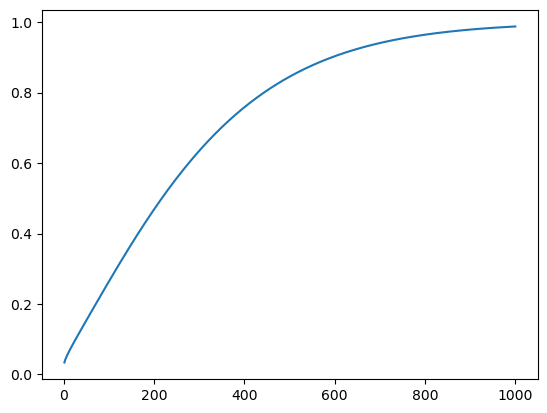

In [58]:
x = np.linspace(0.6,1,1000)
n= np.linspace(1,1000,1000)
mu0 = 0.83
delta = 0.05
alpha = 0.05

sigma0 = np.sqrt(mu0*(1-mu0)/n)
z0 = stats.norm.ppf(1-alpha/2,0,1)
cutoff = mu0 - z0*sigma0

beta = 1 - stats.norm.cdf(cutoff,loc=mu1,scale=sigma0)

plt.plot(n,1-beta)

# This assumes equal variance between the 2 distributions ...
this is realted ot sample vs sample testing (where you need to pool vairances) vs sample vs population - where you just take one variance

# aligns with https://clincalc.com/stats/samplesize.aspx

# using proper variance estimates 


$$ n = \dfrac{({\sqrt{(p-\delta)(1-(p-\delta))} Z_{\beta} + \sqrt{p(1-p)}Z_{\alpha/2}})^2}{\delta^2}

In [59]:
p = 0.83
delta = 0.05
Zb = stats.norm.ppf(1-0.2,0,1)
Za2 = stats.norm.ppf(1-(0.05/2),0,1)

n = (np.sqrt((p-delta)*(1-(p-delta)))*Zb + np.sqrt(p*(1-p))*Za2)**2/delta**2
n

470.7730384192787

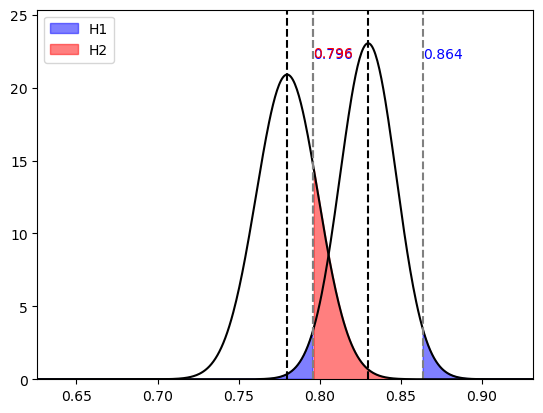

In [60]:
# visualise these 2 hypothesis the calculated
delta = 0.05
alpha = 0.05
beta = 0.2
n = n

# distribution under H0 - mu = 0.83
mu0 = specificity
sigma0 = np.sqrt(mu0*(1-mu0)/n)
x = np.linspace(mu-8*sigma,mu+4*sigma,500)

# # calcualte hte distribution under H1 - mu = 0.78
mu1 = specificity - delta
sigma1 = np.sqrt(mu1*(1-mu1)/n)
# calculate the z-score for the upper bound
z1= stats.norm.ppf(1-beta,0,1)

fig, ax = plt.subplots()
y0 = plot_normal(ax,x,mu0,sigma0,p=0.05,type="two_sided",label="H1",color="blue")
y1 = plot_normal(ax,x,mu1,sigma1,p=0.2,type="right",label="H2",color="red")

plt.ylim(0,max(max(y0),max(y1))*1.1)
plt.xlim(min(x),max(x))
plt.legend()

471.0


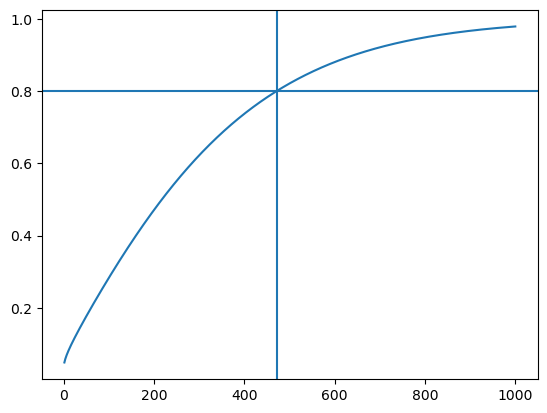

In [61]:
n= np.linspace(1,1000,1000)
mu0 = 0.83
delta = 0.05
alpha = 0.05

sigma0 = np.sqrt(mu0*(1-mu0)/n)
z0 = stats.norm.ppf(1-alpha/2,0,1)
cutoff = mu0 - z0*sigma0
mu1 = mu0-delta
sigma1 = np.sqrt(mu1*(1-mu1)/n)
beta = 1 - stats.norm.cdf(cutoff,loc=mu1,scale=sigma1)

index = np.argmin(np.abs((1-beta) - 0.8))
plt.axhline((1-beta)[index])
plt.axvline(n[index])
print(n[index])
plt.plot(n,1-beta)

# $$ Q.I.D$$

# Imbalanced datasets

To maintain desired power levels with unequal allocation hte total sample size needs to be increased - the required sample size is scaled by 

$$ \dfrac{1+k}{k} $$


In [62]:
# so if we have a prevalance of 0.06 in our diagnostic study we will be enrolling

prevalence = 0.5
k = prevalence/(1-prevalence)
adjustment = (1+k)/k
adjustment
print(f"k: {k}, adjustment: {adjustment}")

k: 1.0, adjustment: 2.0


# Calculating with one sided 

In [63]:
p = 0.83
delta = 0.05
Zb = stats.norm.ppf(1-0.2,0,1)
Za2 = stats.norm.ppf(1-(0.05),0,1)

n = (np.sqrt((p-delta)*(1-(p-delta)))*Zb + np.sqrt(p*(1-p))*Za2)**2/delta**2
n

373.6484805542301

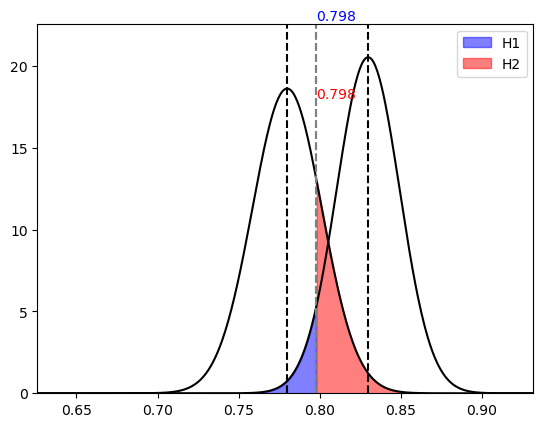

In [64]:
# visualise these 2 hypothesis the calculated
delta = 0.05
alpha = 0.05
beta = 0.2
n = n

# distribution under H0 - mu = 0.83
mu0 = specificity
sigma0 = np.sqrt(mu0*(1-mu0)/n)
x = np.linspace(mu-8*sigma,mu+4*sigma,500)

# # calcualte hte distribution under H1 - mu = 0.78
mu1 = specificity - delta
sigma1 = np.sqrt(mu1*(1-mu1)/n)
# calculate the z-score for the upper bound
z1= stats.norm.ppf(1-beta,0,1)

fig, ax = plt.subplots()
y0 = plot_normal(ax,x,mu0,sigma0,p=0.05,type="left",label="H1",color="blue")
y1 = plot_normal(ax,x,mu1,sigma1,p=0.2,type="right",label="H2",color="red")

plt.ylim(0,max(max(y0),max(y1))*1.1)
plt.xlim(min(x),max(x))
plt.legend()

# Issues with this binomial approximation

https://www.tandfonline.com/doi/pdf/10.1198/000313002317572835



The above code uses a normal approximation of the binomial - however there are issues with this when dealing with small sample sizes and with high sensitivities and specificities - issues arise so we can use hte binomial distribution directly

In [65]:
cutoff = stats.binom.ppf(0.025,n,p)
cutoff / n

nan

In [66]:
power = stats.binom.cdf(6,10,0.1)
power

0.9999908784

In [67]:
# H0 = p = 0.83
# we want 0.025% chance that the mean of the sample is less than the cutoff

# Parameters
n = 400
p = 0.83
delta = 0.05

cutoff_n = stats.binom.ppf(0.025,n,p) # note cutoff is presentied as a number of positives rather than a proportion
cutoff_p = cutoff_n / n

# calculate power at that cutoff
# h1 = 
power = stats.binom.cdf(cutoff_n,n,p-delta)
power

0.7445594292894757

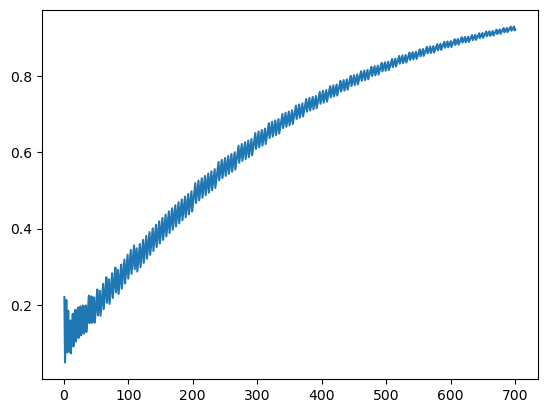

In [91]:
# plot n vs power
# Parameters
n = np.linspace(1,700,700)
p = 0.83
delta = 0.05

cutoff_n = stats.binom.ppf(0.025,n,p) # note cutoff is presentied as a number of positives rather than a proportion
cutoff_p = cutoff_n / n

# calculate power at that cutoff
# h1 = 
power = stats.binom.cdf(cutoff_n,n,p-delta)
plt.plot(n,power)

In [92]:
# # calculate n for a given power
# # find largest n for which all subsequent n's lead to a power > 0.8
# min(np.where(power[::-1] < 0.8)

# find last n for which power is less than 0.8
index = np.where(power <= 0.8)[0].max()
n[index]

473.0

# replicating MKPOWER

In [93]:
# ns <- 2:1000
# lows <- qbinom(1 - power, size = ns, prob = prob) - 1
# crit <- pbinom(lows, size = ns, prob = prob.delta, lower.tail = FALSE) - sig.level
# ind <- max(which(crit > 0)) + 1
# n <- ns[ind]
# print(n)

In [185]:
n = np.arange(2,1001)
#plt.plot(n,stats.binom.ppf(0.2,n,0.83))
lows = stats.binom.ppf(0.2,n,0.83) - 1# calculates number of cases which there is a 0.2 chance to be less than given n trials and prob psamples will contain less than #wuantile function
crit = (1 - stats.binom.cdf(lows,n,0.78)) - 0.05
index = np.max(np.where(crit > 0)) + 1
n[index]

425

# MKPOWER PACKAGE DOES IT BACKWARDS!!! 

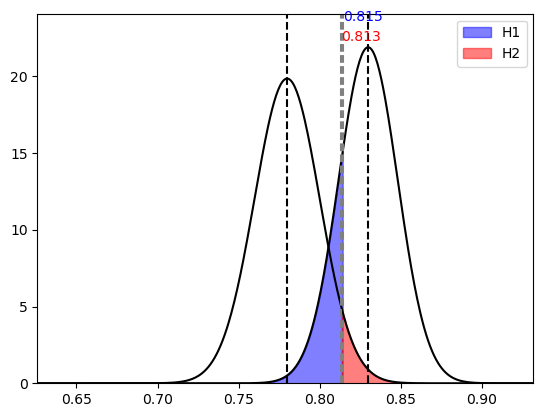

In [205]:
# visualise these 2 hypothesis the calculated
delta = 0.05
beta = 0.2
n = 425

# distribution under H0 - mu = 0.83
mu0 = specificity
sigma0 = np.sqrt(mu0*(1-mu0)/n)
x = np.linspace(mu-8*sigma,mu+4*sigma,500)

# # calcualte hte distribution under H1 - mu = 0.78
mu1 = specificity - delta
sigma1 = np.sqrt(mu1*(1-mu1)/n)

fig, ax = plt.subplots()
y0 = plot_normal(ax,x,mu0,sigma0,p=0.2,type="left",label="H1",color="blue")
y1 = plot_normal(ax,x,mu1,sigma1,p=0.05,type="right",label="H2",color="red")

plt.ylim(0,max(max(y0),max(y1))*1.1)
plt.xlim(min(x),max(x))
plt.legend()

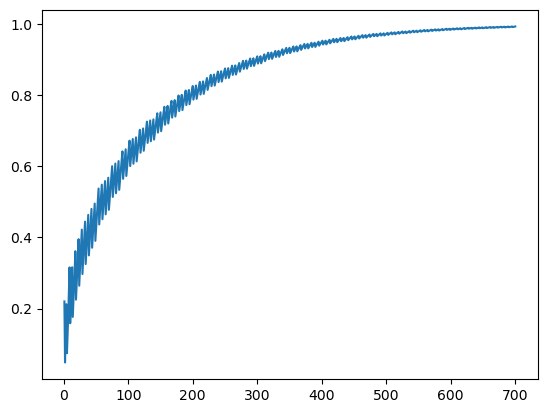

In [209]:
# plot n vs power
# Parameters
n = np.linspace(1,700,700)
p = 0.83
delta = 0.05

cutoff_n = stats.binom.ppf(0.2,n,p) - 1# note cutoff is presentied as a number of positives rather than a proportion
cutoff_p = cutoff_n / n

# calculate power at that cutoff
# h1 = 
power = stats.binom.cdf(cutoff_n,n,p-delta) 
plt.plot(n,power)

In [210]:
index = np.where(power <= 0.95)[0].max()
n[index]

424.0

Inutitively this would mean

H0 = specificiity is 0.78 - we will regect this with 95% confidence if our sample is above hte cutoff value
alternative hypothesis = specificity is 0.83 - sample will only be below this 0.2 of the time - 

THIS ACTUALLY MAKES MORE SENSE

assuming hte alternative hypothesis that the specificity is 0.83 we will reject the null hypothesis with 0.95% confidence 80% of the time!!! WOW